# 집단이 한개 -> 생존함수 추정

# 생존함수 추정량의 분산 : log-log 변환에 의한 신뢰구간 추정

In [5]:
# !pip install lifelines

In [2]:
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter

# 데이터
aml = np.array([9,13,13,18,23,28,31,34,45,48,161])
status = np.array([1,1,0,1,1,0,1,1,0,1,0])  # 1: event, 0: censored

# 생존곡선 모델 생성 및 학습
kmf = KaplanMeierFitter()
kmf.fit(durations=aml, event_observed=status)

# 생존함수 요약 출력
summary_df = kmf.survival_function_.join(kmf.confidence_interval_)  # 생존률 + 신뢰구간
print(summary_df) 

          KM_estimate  KM_estimate_lower_0.95  KM_estimate_upper_0.95
timeline                                                             
0.0          1.000000                1.000000                1.000000
9.0          0.909091                0.508080                0.986674
13.0         0.818182                0.447429                0.951162
18.0         0.715909                0.350190                0.899024
23.0         0.613636                0.265752                0.835299
28.0         0.613636                0.265752                0.835299
31.0         0.490909                0.167331                0.753400
34.0         0.368182                0.092830                0.657041
45.0         0.368182                0.092830                0.657041
48.0         0.184091                0.011738                0.525015
161.0        0.184091                0.011738                0.525015


In [3]:
# KM_estimate : Kaplan-Meier S(t)의 추정량 
# KM_estimate_lower_0.95 : 95% CI 하한 (default: log-log 변환)
# KM_estimate_upper_0.95 : 95% CI 상한 (default: log-log 변환)

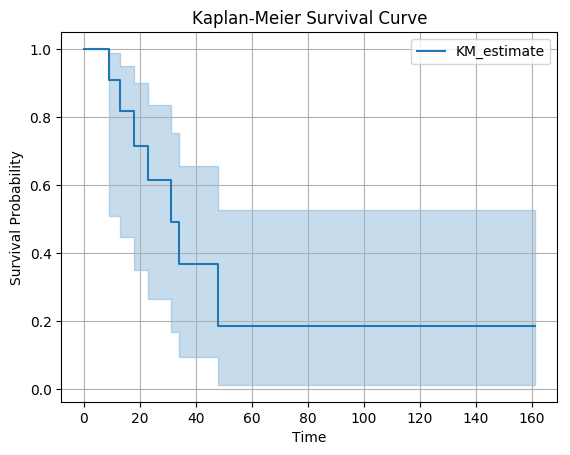

In [4]:
# 생존 그래프 시각화 
import matplotlib.pyplot as plt

kmf.plot(ci_show=True)
plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

# # Nelson-Alen 으로 누적 위험함수 추정

In [20]:
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter

# 데이터 입력
aml = np.array([9,13,13,18,23,28,31,34,45,48,161])
status = np.array([1,1,0,1,1,0,1,1,0,1,0])

# KM 모델 적합
kmf = KaplanMeierFitter()
kmf.fit(aml, event_observed=status)

# KaplanMeierFitter 내부 속성 추출
timeline = kmf.event_table.index.values        # 시점
n_risk = kmf.event_table.at_risk.values        # 위험군 수
n_event = kmf.event_table.observed.values      # 사건 발생 수

# Nelson-Aalen 누적 위험함수 H(t) 계산
hazard_increment = n_event / n_risk
H_hat = np.cumsum(hazard_increment)

# 분산 계산
H_hat_var = np.cumsum(n_event / (n_risk ** 2))
H_hat_se = np.sqrt(H_hat_var)

# 결과 정리
df = pd.DataFrame({
    'Time': timeline,
    'n_risk': n_risk,
    'n_event': n_event,
    'H(t)': np.round(H_hat, 3),
    'SE(H)': np.round(H_hat_se, 3)
})
df

,Time,n_risk,n_event,H(t),SE(H)
0,0.0,11,0,0.000,0.000
1,9.0,11,1,0.091,0.091
2,13.0,10,1,0.191,0.135
3,18.0,8,1,0.316,0.184
4,23.0,7,1,0.459,0.233
5,28.0,6,0,0.459,0.233
6,31.0,5,1,0.659,0.307
7,34.0,4,1,0.909,0.396
8,45.0,3,0,0.909,0.396
9,48.0,2,1,1.409,0.638


# Kaplan - Meier 로 누적 위험함수 추정

In [21]:
# 값 추출
timeline = kmf.event_table.index.values
n_risk = kmf.event_table.at_risk.values
n_event = kmf.event_table.observed.values
surv_prob = kmf.survival_function_['KM_estimate'].values

# 누적 위험함수 (Kaplan 기반): -log(S(t))
H_tilde = -np.log(surv_prob)

# 분산 계산 (Kaplan 기반 분산)
var_tilde = np.cumsum(n_event / (n_risk * (n_risk - n_event)))
se_tilde = np.sqrt(var_tilde)

# 정리
df = pd.DataFrame({
    'Time': timeline,
    'n_risk': n_risk,
    'n_event': n_event,
    'S(t)': np.round(surv_prob, 4),
    'H_tilde (-log S)': np.round(H_tilde, 4),
    'Var(H_tilde)': np.round(var_tilde, 4),
    'SE(H_tilde)': np.round(se_tilde, 4)
})
df

,Time,n_risk,n_event,S(t),H_tilde (-log S),Var(H_tilde),SE(H_tilde)
0,0.0,11,0,1.0000,-0.0000,0.0000,0.0000
1,9.0,11,1,0.9091,0.0953,0.0091,0.0953
2,13.0,10,1,0.8182,0.2007,0.0202,0.1421
3,18.0,8,1,0.7159,0.3342,0.0381,0.1951
4,23.0,7,1,0.6136,0.4884,0.0619,0.2487
5,28.0,6,0,0.6136,0.4884,0.0619,0.2487
6,31.0,5,1,0.4909,0.7115,0.1119,0.3345
7,34.0,4,1,0.3682,0.9992,0.1952,0.4418
8,45.0,3,0,0.3682,0.9992,0.1952,0.4418
9,48.0,2,1,0.1841,1.6923,0.6952,0.8338


In [ ]:
# H_tilde (-log S) : 누적위험함수 추정 
# Var(H_tilde) : 누적 위험함수의 분산 

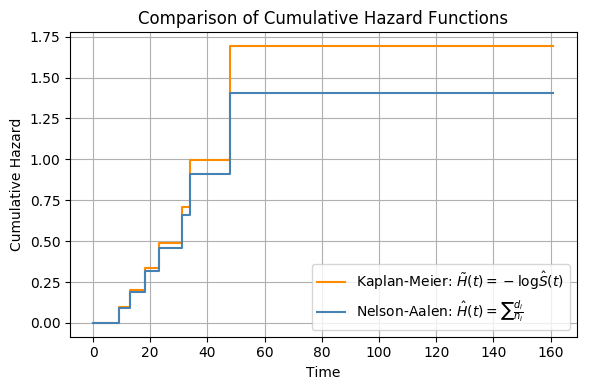

In [26]:
# 시각화
plt.figure(figsize=(6,4))
plt.step(timeline, H_tilde, where="post", label=r"Kaplan-Meier: $\tilde{H}(t) = -\log \hat{S}(t)$", \
         color="darkorange")
plt.step(timeline, H_hat, where="post", label=r"Nelson-Aalen: $\hat{H}(t) = \sum \frac{d_i}{n_i}$", \
         color="steelblue")
plt.xlabel("Time")
plt.ylabel("Cumulative Hazard")
plt.title("Comparison of Cumulative Hazard Functions")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 이집단에 대한 로그-순위 검정

In [6]:
# 귀무가설 : 두 모집단의 생존함수가 같다
# 대립가설 : 적어도 연구기간의 일부분에서 두 모집단의 생존함수가 같지 않다. 

In [10]:
import numpy as np
from lifelines.statistics import logrank_test

# 데이터
time1 = np.array([50,49,56,68,74,69,70,67,74,81,61,75])
status1 = np.array([1,0,1,1,0,0,0,1,0,0,1,0])

time2 = np.array([63,52,70,75,72,69,70,70,74,81,58,73])
status2 = np.array([0,1,0,1,1,0,0,1,0,0,1,0])

# 로그 순위 검정 수행
results = logrank_test(
    time1, time2, 
    event_observed_A=status1, 
    event_observed_B=status2
)

# summary DataFrame을 직접 출력
display(results.summary)

,test_statistic,p,-log2(p)
0,0.074841,0.784414,0.350312


In [11]:
# p-value 값이 0.78로 유의수준 0.05에서 귀무가설을 기각한다. 두 모집단의 생존함수가 같다고 할 수 있다. 

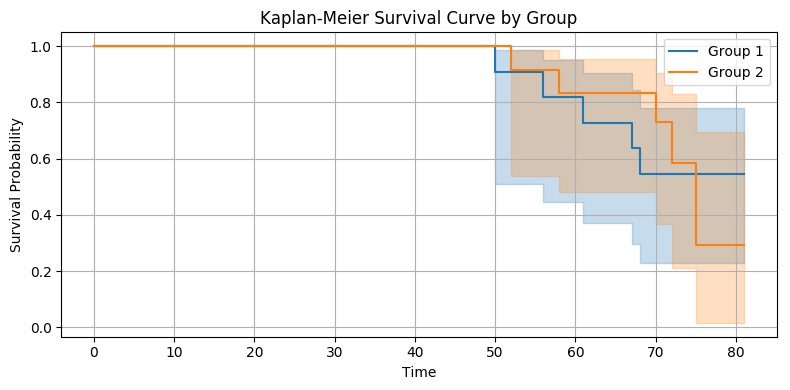

In [13]:
# KM 모델 생성
kmf1 = KaplanMeierFitter()
kmf2 = KaplanMeierFitter()

# 모델 피팅
kmf1.fit(time1, event_observed=status1, label='Group 1')
kmf2.fit(time2, event_observed=status2, label='Group 2')

# 시각화
plt.figure(figsize=(8,4))
kmf1.plot_survival_function(ci_show=True)
kmf2.plot_survival_function(ci_show=True)
plt.title("Kaplan-Meier Survival Curve by Group")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 다중 집단에 대한 로그-순위 검정

In [27]:
# 귀무가설 : K개의 모집단의 생존함수가 같다
# 대립가설 : 적어도 연구기간의 일부분에서 어떤 한 개의 생존함수는 나머지의 생존함수와 다르다.

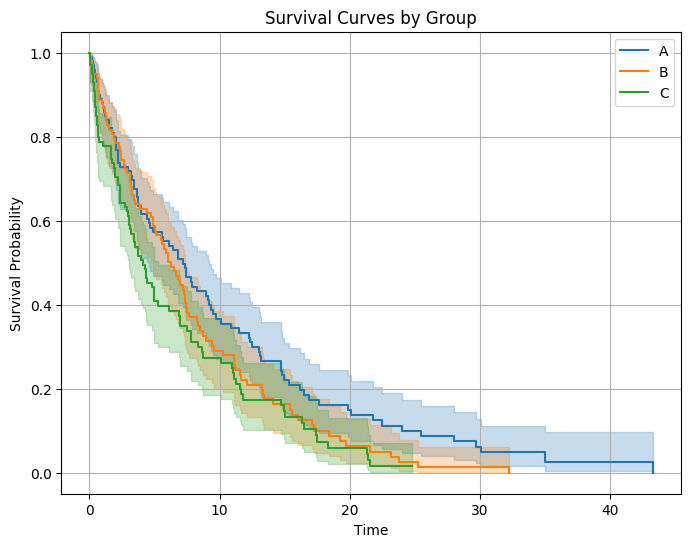

>>> 로그순위 검정 결과 (Pairwise Log-rank Test)


test_statistic         p  -log2(p)
A B        3.087107  0.078915  3.663557
  C        6.918570  0.008531  6.873151
B C        1.643987  0.199779  2.323521

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import pairwise_logrank_test

# 샘플 데이터 생성
np.random.seed(42)

# 세 그룹: A, B, C
data = []

for group in ['A', 'B', 'C']:
    n = 100
    if group == 'A':
        survival_time = np.random.exponential(scale=10, size=n)
    elif group == 'B':
        survival_time = np.random.exponential(scale=7, size=n)
    else:
        survival_time = np.random.exponential(scale=5, size=n)

    event_occurred = np.random.binomial(1, 0.9, size=n)

    df = pd.DataFrame({
        'time': survival_time,
        'event': event_occurred,
        'group': group
    })
    data.append(df)

df_all = pd.concat(data)

# 생존곡선 시각화
kmf = KaplanMeierFitter()
plt.figure(figsize=(8, 6))

for name, grouped_df in df_all.groupby('group'):
    kmf.fit(grouped_df['time'], event_observed=grouped_df['event'], label=name)
    kmf.plot_survival_function()

plt.title('Survival Curves by Group')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.grid()
plt.show()

# 로그 순위 검정 (다중 그룹)
results = pairwise_logrank_test(df_all['time'], df_all['group'], event_observed=df_all['event'])

# 결과 요약
print(">>> 로그순위 검정 결과 (Pairwise Log-rank Test)")
display(results.summary)

# 층화 로그-순위 검정 
- 어떤 변수를 통제한 생존함수를 추정해 비교

In [28]:
# 귀무가설 : K개의 모집단의 생존함수가 같다 
# 대립가설 : 적어도 연구기간의 일부분에서 어떤 한 개의 생존함수는 나머지의 생존함수와 다르다.
# K개의 모집단에서 발생한 데이터는 각 집단에서 S개의 층을 갖는다. 

In [6]:
import numpy as np
import pandas as pd
from lifelines.statistics import logrank_test
from scipy.stats import chi2
import matplotlib.pyplot as plt

# 샘플 데이터 생성
np.random.seed(0)

def generate_group(n, scale, group_name, stratum_name):
    return pd.DataFrame({
        'time': np.random.exponential(scale=scale, size=n),
        'event': np.random.binomial(1, 0.9, size=n),
        'group': group_name,
        'stratum': stratum_name
    })

# 두 그룹(A, B), 두 층(Stratum 1, 2)
df = pd.concat([
    generate_group(100, 8, 'A', 'S1'),
    generate_group(100, 6, 'B', 'S1'),
    generate_group(100, 10, 'A', 'S2'),
    generate_group(100, 5, 'B', 'S2')
])

# 층화 로그순위 검정: 각 층의 통계량을 누적
total_stat = 0
df_total = 0  # 자유도

for stratum, stratum_df in df.groupby('stratum'):
    result = logrank_test(
        stratum_df[stratum_df['group'] == 'A']['time'],
        stratum_df[stratum_df['group'] == 'B']['time'],
        event_observed_A=stratum_df[stratum_df['group'] == 'A']['event'],
        event_observed_B=stratum_df[stratum_df['group'] == 'B']['event']
    )
    print(f"\n Stratum: {stratum}")
    print(result.summary)

    # 수정된 부분: .values[0] 제거하고 바로 더하기!
    total_stat += result.test_statistic
    df_total += 1

# 최종 p-value 계산
p_value = 1 - chi2.cdf(total_stat, df=df_total)

print("\n===== 층화 로그순위 검정 결과 =====")
print(f"총 합산 검정 통계량 (chi²): {total_stat:.4f}")
print(f"자유도: {df_total}")
print(f"p-value: {p_value:.4f}")


 Stratum: S1
   test_statistic         p  -log2(p)
0        1.147497  0.284074  1.815662

 Stratum: S2
   test_statistic             p   -log2(p)
0       24.360846  7.987576e-07  20.255739

===== 층화 로그순위 검정 결과 =====
총 합산 검정 통계량 (chi²): 25.5083
자유도: 2
p-value: 0.0000


# 모수적 검정 

- 지수분포를 따를때
$ f(t) = \lambda e^{-\lambda t},\quad t \geq 0$

중간수명 (Median survival time): 3.4657


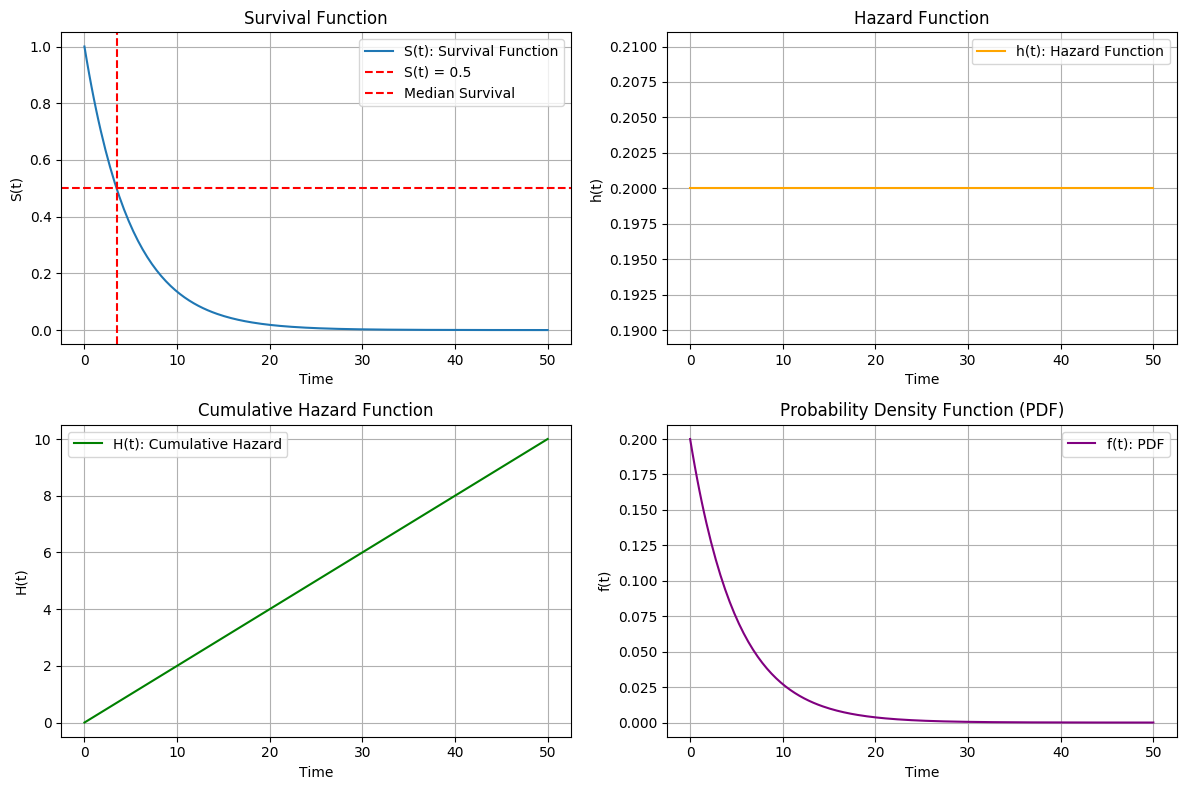

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 파라미터 설정
lambda_ = 0.2  # 지수분포의 λ (위험률)
t = np.linspace(0, 50, 200)

# 함수 정의
survival = np.exp(-lambda_ * t)                     # 생존함수 S(t)
hazard = np.full_like(t, lambda_)                   # 위험함수 h(t) = 상수
cumulative_hazard = lambda_ * t                     # 누적위험함수 H(t)
median_survival = np.log(2) / lambda_               # 중간수명

print(f"중간수명 (Median survival time): {median_survival:.4f}")

# 그래프 그리기
plt.figure(figsize=(12, 8))

# 생존함수
plt.subplot(2, 2, 1)
plt.plot(t, survival, label='S(t): Survival Function')
plt.axhline(0.5, color='red', linestyle='--', label='S(t) = 0.5')
plt.axvline(median_survival, color='red', linestyle='--', label='Median Survival')
plt.title('Survival Function')
plt.xlabel('Time')
plt.ylabel('S(t)')
plt.grid()
plt.legend()

# 위험함수
plt.subplot(2, 2, 2)
plt.plot(t, hazard, label='h(t): Hazard Function', color='orange')
plt.title('Hazard Function')
plt.xlabel('Time')
plt.ylabel('h(t)')
plt.grid()
plt.legend()

# 누적위험함수
plt.subplot(2, 2, 3)
plt.plot(t, cumulative_hazard, label='H(t): Cumulative Hazard', color='green')
plt.title('Cumulative Hazard Function')
plt.xlabel('Time')
plt.ylabel('H(t)')
plt.grid()
plt.legend()

# PDF도 함께 시각화하면 직관적
pdf = lambda_ * np.exp(-lambda_ * t)
plt.subplot(2, 2, 4)
plt.plot(t, pdf, label='f(t): PDF', color='purple')
plt.title('Probability Density Function (PDF)')
plt.xlabel('Time')
plt.ylabel('f(t)')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

추정된 λ (hazard rate): 0.1720
추정된 중간수명: 4.0301


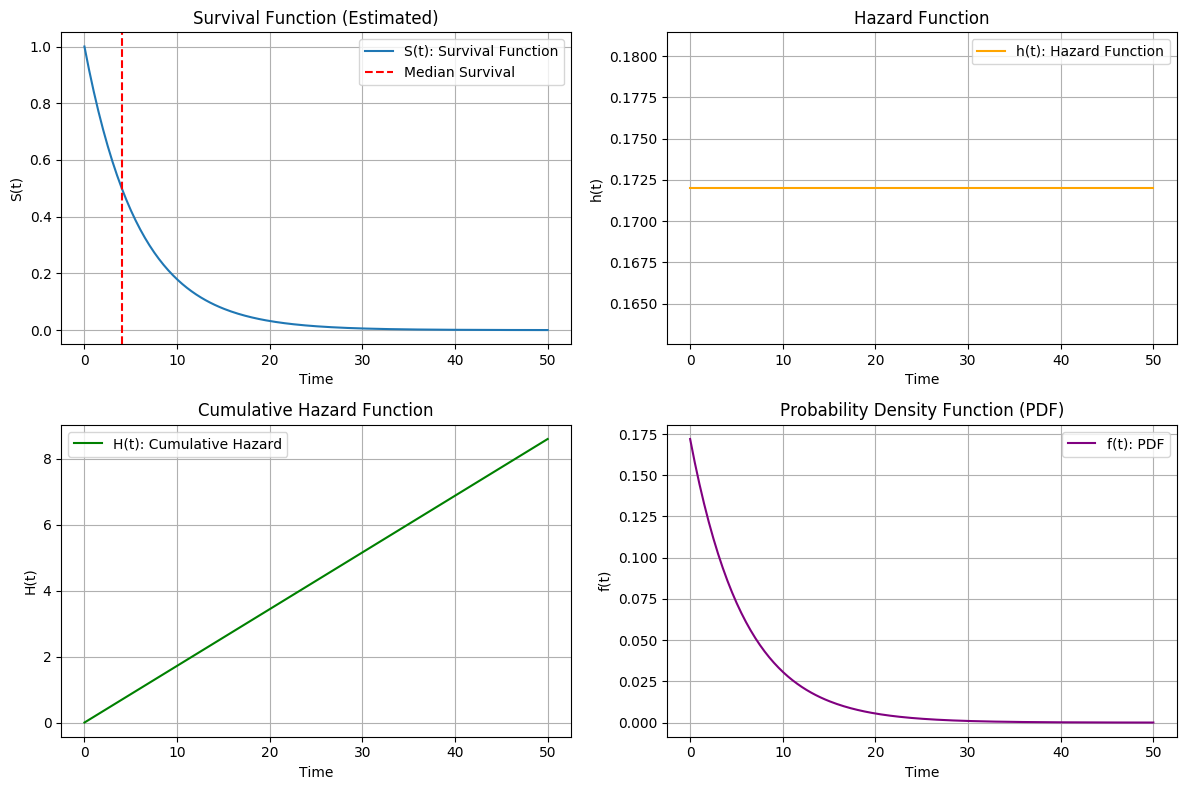

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 예제 생존 데이터 생성 (검열 포함)
np.random.seed(0)
n = 100
true_lambda = 0.2
time = np.random.exponential(scale=1/true_lambda, size=n)  # T ~ Exp(λ)
event = np.random.binomial(1, 0.8, size=n)  # 80%는 사건 발생, 20%는 검열

# DataFrame 구성
df = pd.DataFrame({'time': time, 'event': event})

# λ 추정 (MLE with censoring) : 단위시간 당 평균 발생 횟수
lambda_hat = df['event'].sum() / df['time'].sum()

print(f"추정된 λ (hazard rate): {lambda_hat:.4f}")

# 생존/위험/누적위험/중간수명 함수 생성
t = np.linspace(0, 50, 200)
S_t = np.exp(-lambda_hat * t)
h_t = np.full_like(t, lambda_hat)
H_t = lambda_hat * t
median_survival = np.log(2) / lambda_hat
print(f"추정된 중간수명: {median_survival:.4f}")

# 시각화
plt.figure(figsize=(12, 8))

# 생존함수
plt.subplot(2, 2, 1)
plt.plot(t, S_t, label='S(t): Survival Function')
plt.axvline(median_survival, color='red', linestyle='--', label='Median Survival')
plt.title('Survival Function (Estimated)')
plt.xlabel('Time')
plt.ylabel('S(t)')
plt.grid()
plt.legend()

# 위험함수
plt.subplot(2, 2, 2)
plt.plot(t, h_t, label='h(t): Hazard Function', color='orange')
plt.title('Hazard Function')
plt.xlabel('Time')
plt.ylabel('h(t)')
plt.grid()
plt.legend()

# 누적위험함수
plt.subplot(2, 2, 3)
plt.plot(t, H_t, label='H(t): Cumulative Hazard', color='green')
plt.title('Cumulative Hazard Function')
plt.xlabel('Time')
plt.ylabel('H(t)')
plt.grid()
plt.legend()

# PDF
pdf = lambda_hat * np.exp(-lambda_hat * t)
plt.subplot(2, 2, 4)
plt.plot(t, pdf, label='f(t): PDF', color='purple')
plt.title('Probability Density Function (PDF)')
plt.xlabel('Time')
plt.ylabel('f(t)')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()